## Linear $q^m_c$ fit

Here we will fit a model without the data points that have $fmc$ values in $[-30, 30]$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

In [2]:
outlier_fpath = "./focal_length_outliers.txt"
with open(outlier_fpath,'r') as f:
  outliers = [l.strip() for l in f.readlines()]

data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)
print(f"Num data points: {len(data)}")

# Remove outliers
data = data[~data['name'].isin(outliers)]
print(f"Num data points after removing outliers: {len(data)}")

Num data points: 3529
Num data points after removing outliers: 3496


In [3]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["h_r_vec" ] = [to_vec_space(v) for v in data["h_r_est"]]
data["v_r_vec" ] = [to_vec_space(v) for v in data["v_r_est"]]
data["a_r_vec" ] = [to_vec_space(v) for v in data["a_r_est"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]

zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

print(f"Number of data points zl034 (all fmc):{zl34.shape[0]}")
print(f"Number of data points zr034 (all fmc):{zr34.shape[0]}")

# remove data points with fmcs between -30 and 30
# zl34 = zl34[(zl34['fmc'] < -100) | (zl34['fmc'] >100)].reset_index(drop=True)
# zr34 = zr34[(zr34['fmc'] < -100) | (zr34['fmc'] >100)].reset_index(drop=True)

print(f"Number of data points zl034 (fmc<-50 | fmc > 50):{zl34.shape[0]}")
print(f"Number of data points zr034 (fmc<-50 | fmc > 50):{zr34.shape[0]}")

Number of data points zl034 (all fmc):326
Number of data points zr034 (all fmc):308
Number of data points zl034 (fmc<-50 | fmc > 50):326
Number of data points zr034 (fmc<-50 | fmc > 50):308


In [4]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx])
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)


In [19]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0.001, 0.001, 0.001, 0.001,
      0.5, 0.5, 0.5, -0.5,
      0.001, 0.001, 0.001, 0.001]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":50})

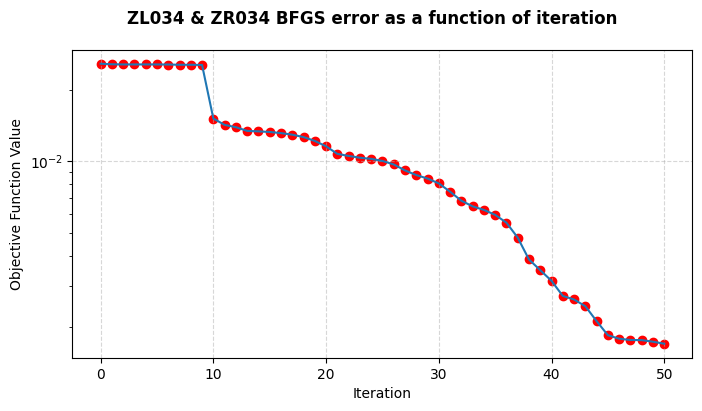

In [13]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [14]:
# with initial conditions: 
#    [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      # 0.5, 0.5, 0.5, 0.5,
      # 0.01, 0.01, 0.01, 0.01,
      # 0.5, 0.5, 0.5, 0.5,
      # 0.01, 0.01, 0.01, 0.01]
# q_rrp = [ 2.40880189e-04, 5.17286849e-05, -5.38532307e-04, -9.99999825e-01]
# q_cm_zl_a = [0.4906213, 0.50447141, 0.50660277, 0.49814955]
# q_cm_zl_b = [0.00988976, 0.01016787, 0.01021132, 0.01004142]
# q_cm_zr_a = [0.50348588, 0.49017226, 0.49884929, 0.5073288]
# q_cm_zr_b = [0.01121036, 0.01090304, 0.01110622, 0.01129375]

# with initial conditions:
# [     0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
#       0.5, 0.5, 0.5, 0.5,
#       0.001, 0.001, 0.001, 0.001,
#       0.5, 0.5, 0.5, 0.5,
#       0.001, 0.001, 0.001, 0.001]
# q_rrp = [ 1.91897340e-04, -3.47489654e-05, -4.26840748e-04, -9.99999890e-01]
# q_cm_zl_a = [0.49055183, 0.50449195, 0.50673774, 0.49805988]
# q_cm_zl_b = [0.00092306, 0.00094891, 0.00095303, 0.00093726]
# q_cm_zr_a = [0.50312761, 0.49037746, 0.49931136, 0.50703128]
# q_cm_zr_b = [0.00101073, 0.00098221, 0.00100063, 0.00101784]

q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_a = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_b = np.array(res.x[8:12])
q_cm_zr_a = np.array(res.x[12:16])/np.linalg.norm(np.array(res.x[12:16]))
q_cm_zr_b = np.array(res.x[16:20])


print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_a:{q_cm_zl_a}")
print(f"q_cm_zl_b:{q_cm_zl_b}")
print(f"q_cm_zr_a:{q_cm_zr_a}")
print(f"q_cm_zr_b:{q_cm_zr_b}")

Final function:0.001708
Final Jacobian:516.401871
q_rrp:[ 1.91897340e-04 -3.47489654e-05 -4.26840748e-04 -9.99999890e-01]
q_cm_zl_a:[0.49055183 0.50449195 0.50673774 0.49805988]
q_cm_zl_b:[0.00092306 0.00094891 0.00095303 0.00093726]
q_cm_zr_a:[0.50312761 0.49037746 0.49931136 0.50703128]
q_cm_zr_b:[0.00101073 0.00098221 0.00100063 0.00101784]


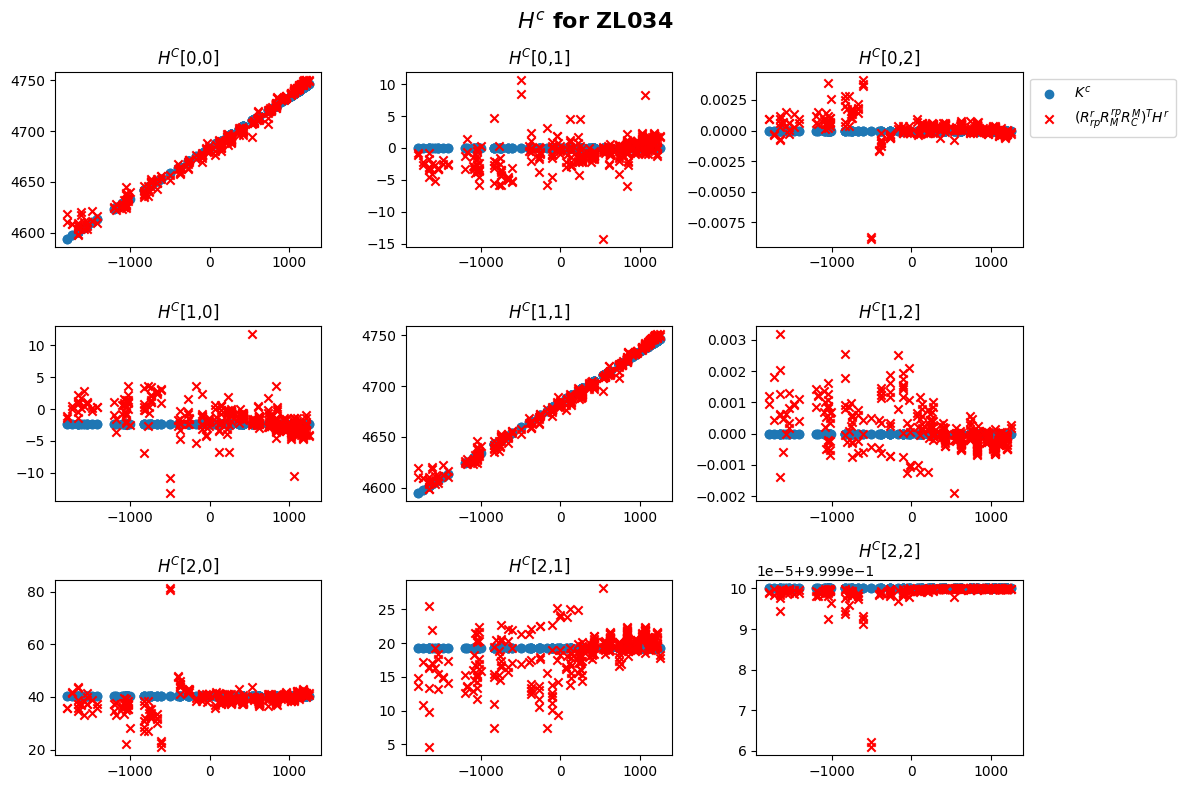

In [15]:
# Compute H_c for ZL034
H_c_model_zl = []
H_c_gt_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl34.shape[0]):
  # compute the rotation R_rc
  f = zl34["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl34))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  # rot_mc = R.from_quat(q_cm_zl_a)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl34)
  H_c_model_zl.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt_zl.append(get_KC(i, zl34).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in H_c_gt_zl], label="expectation")
    ax[r,c].scatter(zl34["fmc"], [H[r, c] for H in H_c_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

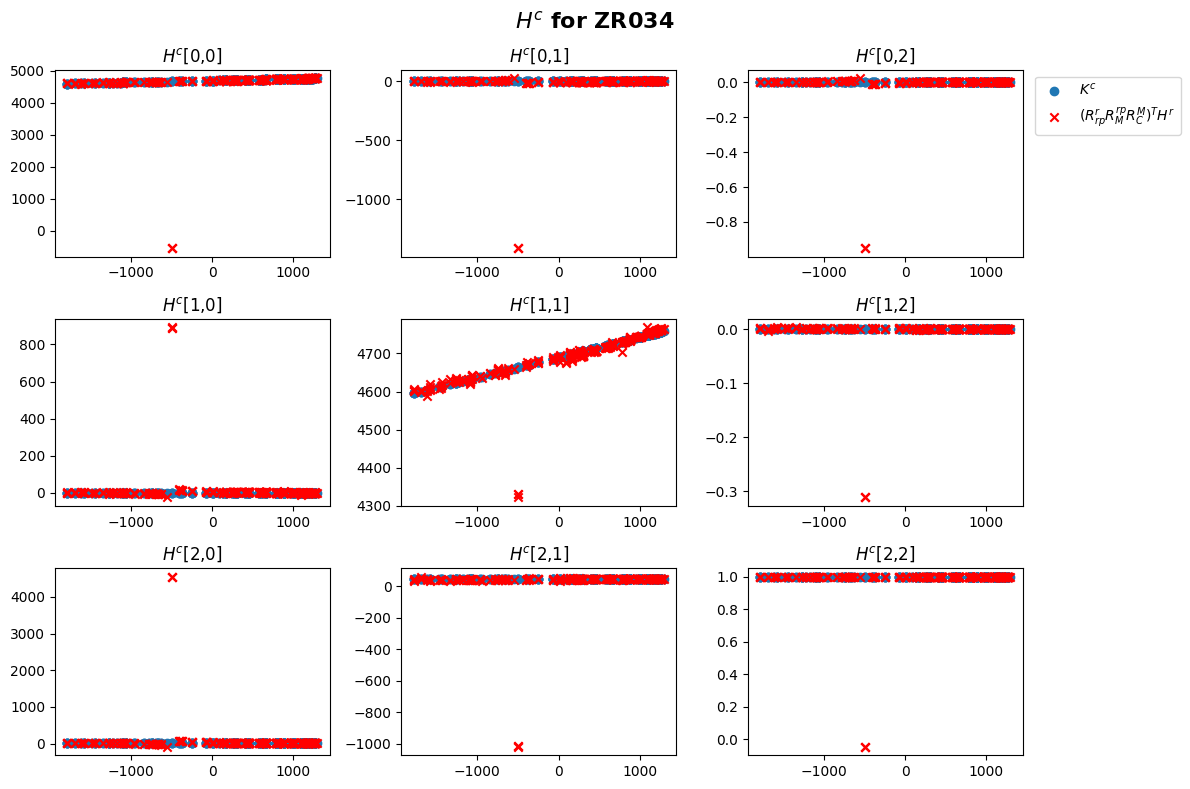

In [16]:
# Compute H_r from model
H_c_model_zr = []
H_c_gt_zr = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * f)
  # rot_mc = R.from_quat(q_cm_zr_a)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model_zr.append(R_rc.T @ H_r)

  H_c_gt_zr.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt_zr], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^c$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))

fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

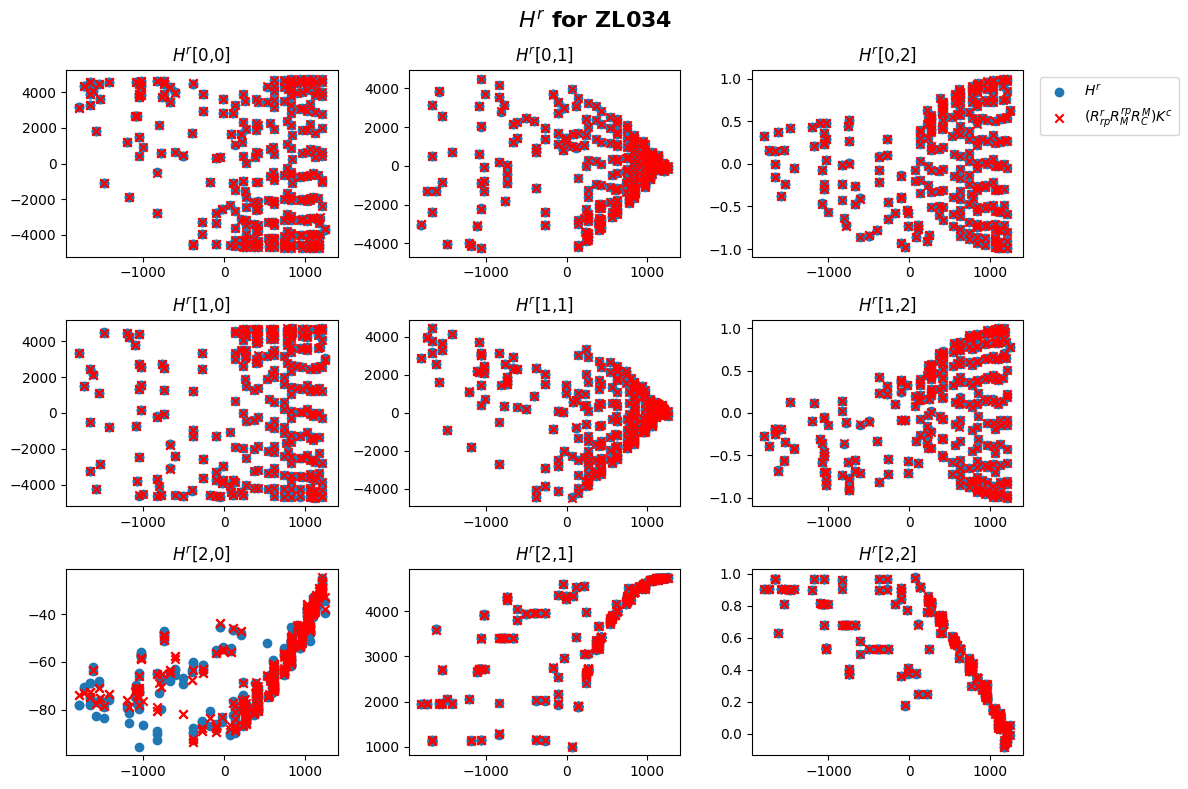

In [17]:
# plot H_r matrix as a function of f
H_r_data_zl = []
H_r_model_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl34.shape[0]):
  # compute model predictions
  rot_rpm = R.from_matrix(get_R_rpm(i, zl34))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * zl34["fmc"][i])
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  H_c = get_KC(i, zl34).T
  H_r_model_zl.append(R_rc @ H_c)

  # data
  H_r_data_zl.append(get_H_r_data(i, zl34))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in H_r_data_zl], label="expectation")
    ax[r,c].scatter(zl34["fmc"], [H[r, c] for H in H_r_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) K^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

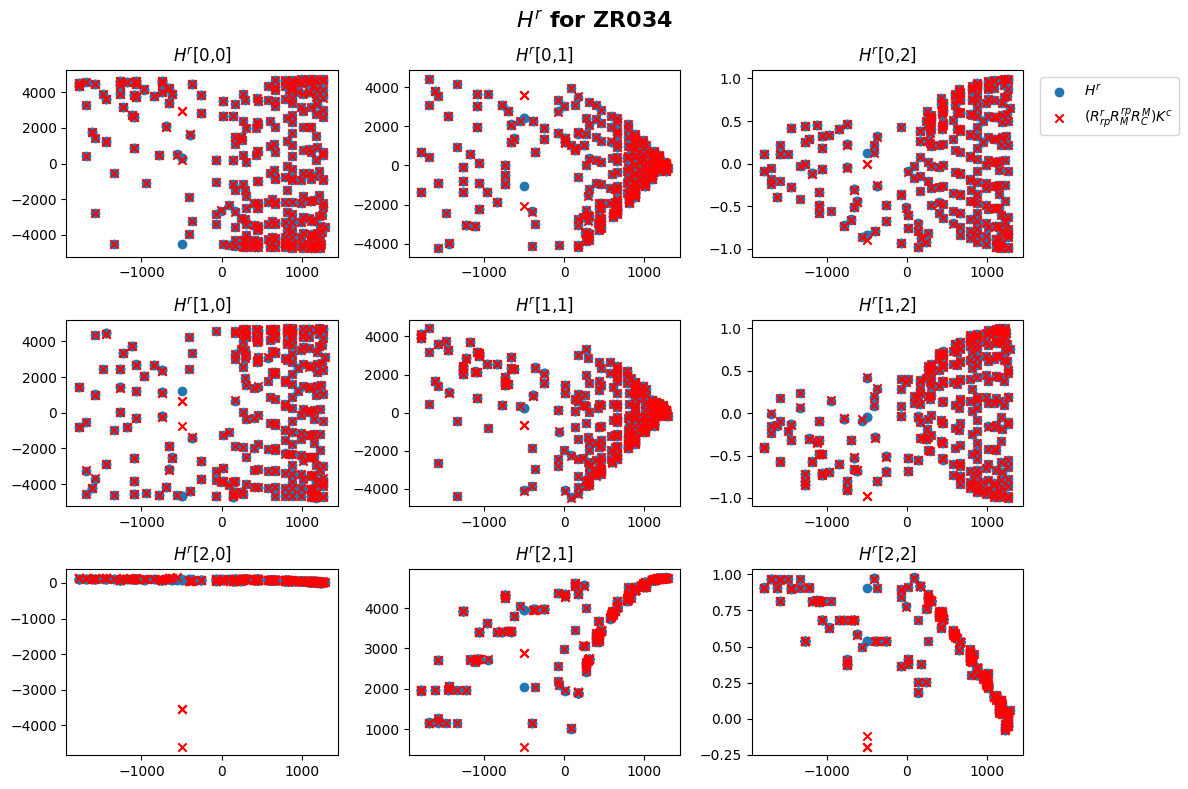

In [18]:
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr34.shape[0]):
  # compute model predictions
  rot_rpm = R.from_matrix(get_R_rpm(i, zr34))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * zr34["fmc"][i])
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  H_c = get_KC(i, zr34).T
  H_r_model_zr.append(R_rc @ H_c)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr34))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr34["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr34["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) K^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()